In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\irene\Desktop\Mis notas Simulacro\tourist_accommodation_10112025_clean.csv")

In [3]:
df.isnull().sum().sort_values(ascending=False)

last_review_date               6506
first_review_date              6442
neighbourhood_district         3656
reviews_per_month              2576
description                     127
review_scores_location          120
review_scores_value             120
review_scores_checkin           119
review_scores_accuracy          114
review_scores_communication     110
review_scores_cleanliness       108
review_scores_rating            105
name                              3
neighbourhood_name                0
host_id                           0
apartment_id                      0
room_type                         0
bedrooms                          0
beds                              0
accommodates                      0
bathrooms                         0
number_of_reviews                 0
availability_365                  0
availability_90                   0
availability_60                   0
availability_30                   0
has_availability                  0
maximum_nights              

# Habitaciones

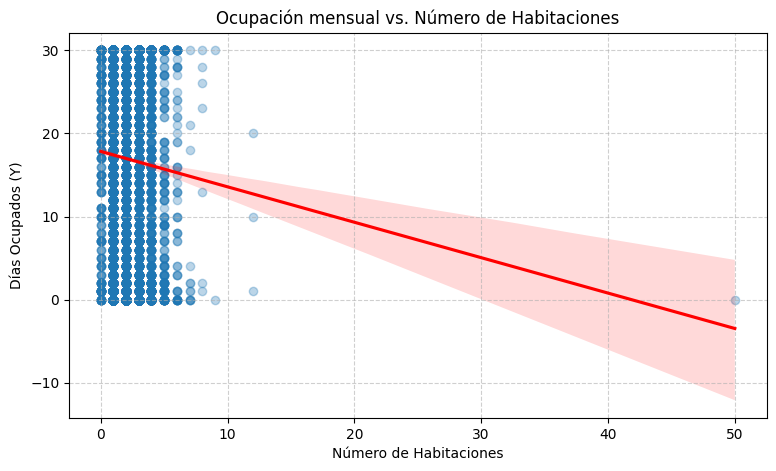

In [17]:
plt.figure(figsize=(9, 5))
# Usamos lmplot para incluir automáticamente la línea de regresión (linealidad)
sns.regplot(
    x='bedrooms', 
    y='ocupacion_mes',
    data=df, 
    scatter_kws={'alpha': 0.3}, # Hacemos los puntos más transparentes
    line_kws={'color': 'red'}  # Línea de regresión roja
)
plt.title('Ocupación mensual vs. Número de Habitaciones')
plt.xlabel('Número de Habitaciones')
plt.ylabel('Días Ocupados (Y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [5]:
df['bedrooms'].value_counts()

bedrooms
1.0     4409
2.0     2205
3.0     1517
4.0      699
0.0      296
5.0      191
6.0       67
7.0       12
8.0        7
12.0       3
9.0        2
50.0       1
Name: count, dtype: int64

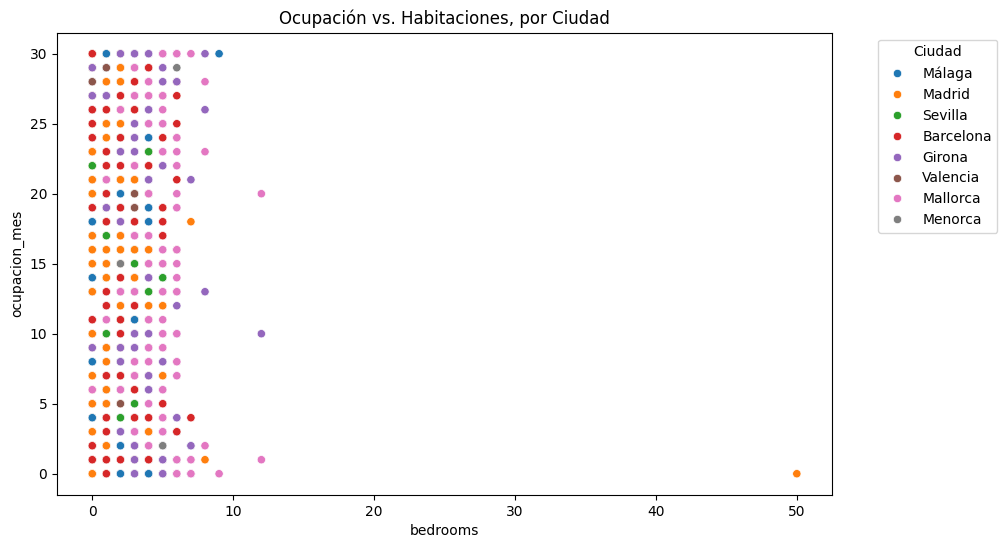

In [18]:
# Gráfico de dispersión con color por Ciudad
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='bedrooms',
    y='ocupacion_mes',
    hue='city',  # Agrega color basado en la ciudad
    data=df
)
plt.title('Ocupación vs. Habitaciones, por Ciudad')
plt.legend(title='Ciudad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Camas

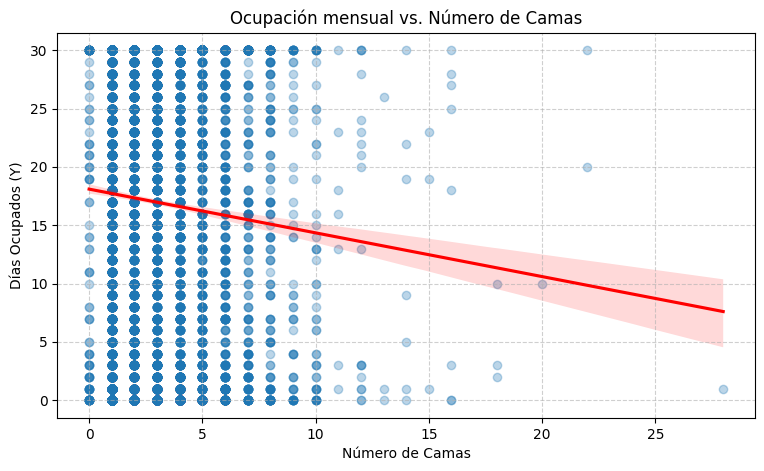

In [15]:
plt.figure(figsize=(9, 5))
# Usamos lmplot para incluir automáticamente la línea de regresión (linealidad)
sns.regplot(
    x='beds', 
    y='ocupacion_mes',
    data=df, 
    scatter_kws={'alpha': 0.3}, # Hacemos los puntos más transparentes
    line_kws={'color': 'red'}  # Línea de regresión roja
)
plt.title('Ocupación mensual vs. Número de Camas')
plt.xlabel('Número de Camas')
plt.ylabel('Días Ocupados (Y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
df[['beds']].value_counts()

beds
1.0     3107
2.0     1819
3.0     1514
4.0     1116
5.0      744
6.0      476
7.0      209
8.0      150
0.0      113
9.0       58
10.0      50
12.0      18
16.0       8
11.0       7
14.0       7
13.0       3
15.0       3
18.0       3
22.0       2
20.0       1
28.0       1
Name: count, dtype: int64

# Baños

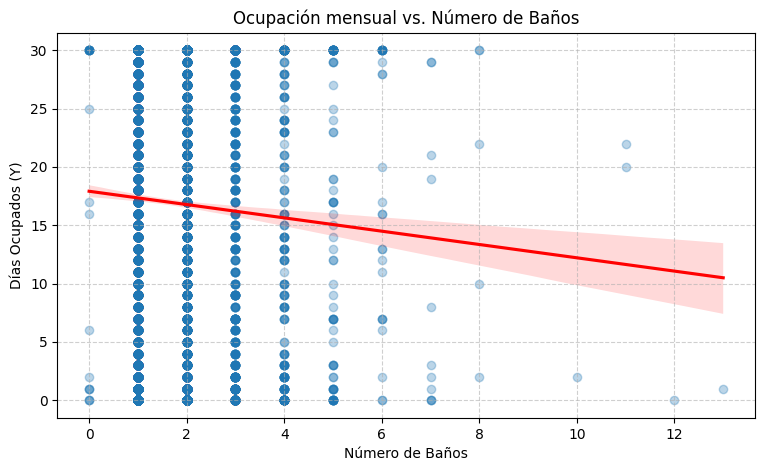

In [14]:
plt.figure(figsize=(9, 5))
# Usamos lmplot para incluir automáticamente la línea de regresión (linealidad)
sns.regplot(
    x='bathrooms', 
    y='ocupacion_mes',
    data=df, 
    scatter_kws={'alpha': 0.3}, # Hacemos los puntos más transparentes
    line_kws={'color': 'red'}  # Línea de regresión roja
)
plt.title('Ocupación mensual vs. Número de Baños')
plt.xlabel('Número de Baños')
plt.ylabel('Días Ocupados (Y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
df[['bathrooms']].value_counts()

bathrooms
1            5768
2            2642
3             620
4             231
5              78
6              28
0              21
7              11
8               5
11              2
10              1
12              1
13              1
Name: count, dtype: int64

# Graficos para comparaciones

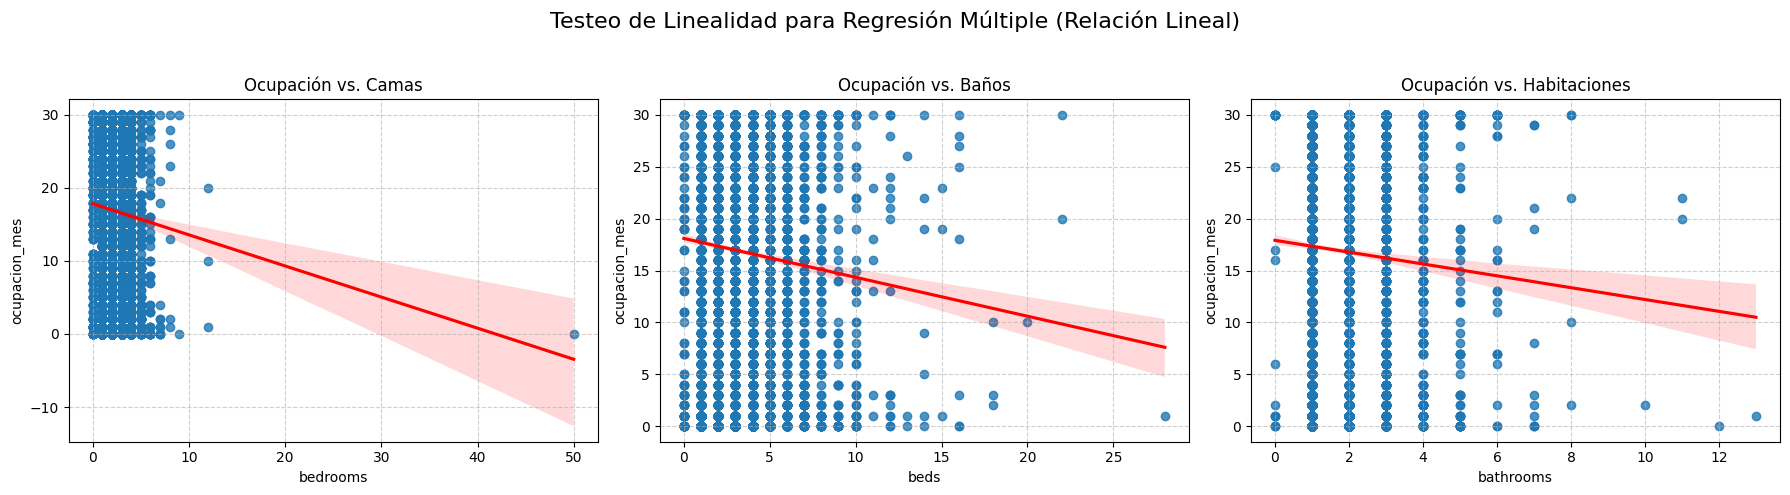

In [ ]:
# --- 1. Definición de la Rejilla ---
# fig: El lienzo completo.
# axes: Un array (matriz) con los 3 espacios para los gráficos.
# (1, 3): Significa 1 Fila, 3 Columnas.
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 
# figsize=(18, 5) da un buen ancho para que los 3 gráficos quepan bien.

# --- 2. Dibujar cada gráfico en su posición ---
# Accedemos a cada posición de la lista 'axes' (la indexación empieza en 0):

# Gráfico 1:  Ocupación vs. Habitaciones (eje en la posición [0])
sns.regplot(x='bedrooms', y='ocupacion_mes', data=df, ax=axes[0], line_kws={'color': 'red'})
axes[2].set_title('Ocupación vs. Habitaciones')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Ocupación vs. Camas (eje en la posición [1])
sns.regplot(x='beds', y='ocupacion_mes', data=df, ax=axes[1], line_kws={'color': 'red'})
axes[0].set_title('Ocupación vs. Camas')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Ocupación vs. Baños (eje en la posición [2])
sns.regplot(x='bathrooms', y='ocupacion_mes', data=df, ax=axes[2], line_kws={'color': 'red'})
axes[1].set_title('Ocupación vs. Baños')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- 3. Ajustes finales ---
fig.suptitle('Testeo de Linealidad para Regresión Múltiple (Relación Lineal)', fontsize=16) 
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajusta el espacio entre gráficos para que no se superpongan los títulos
# 
plt.show()

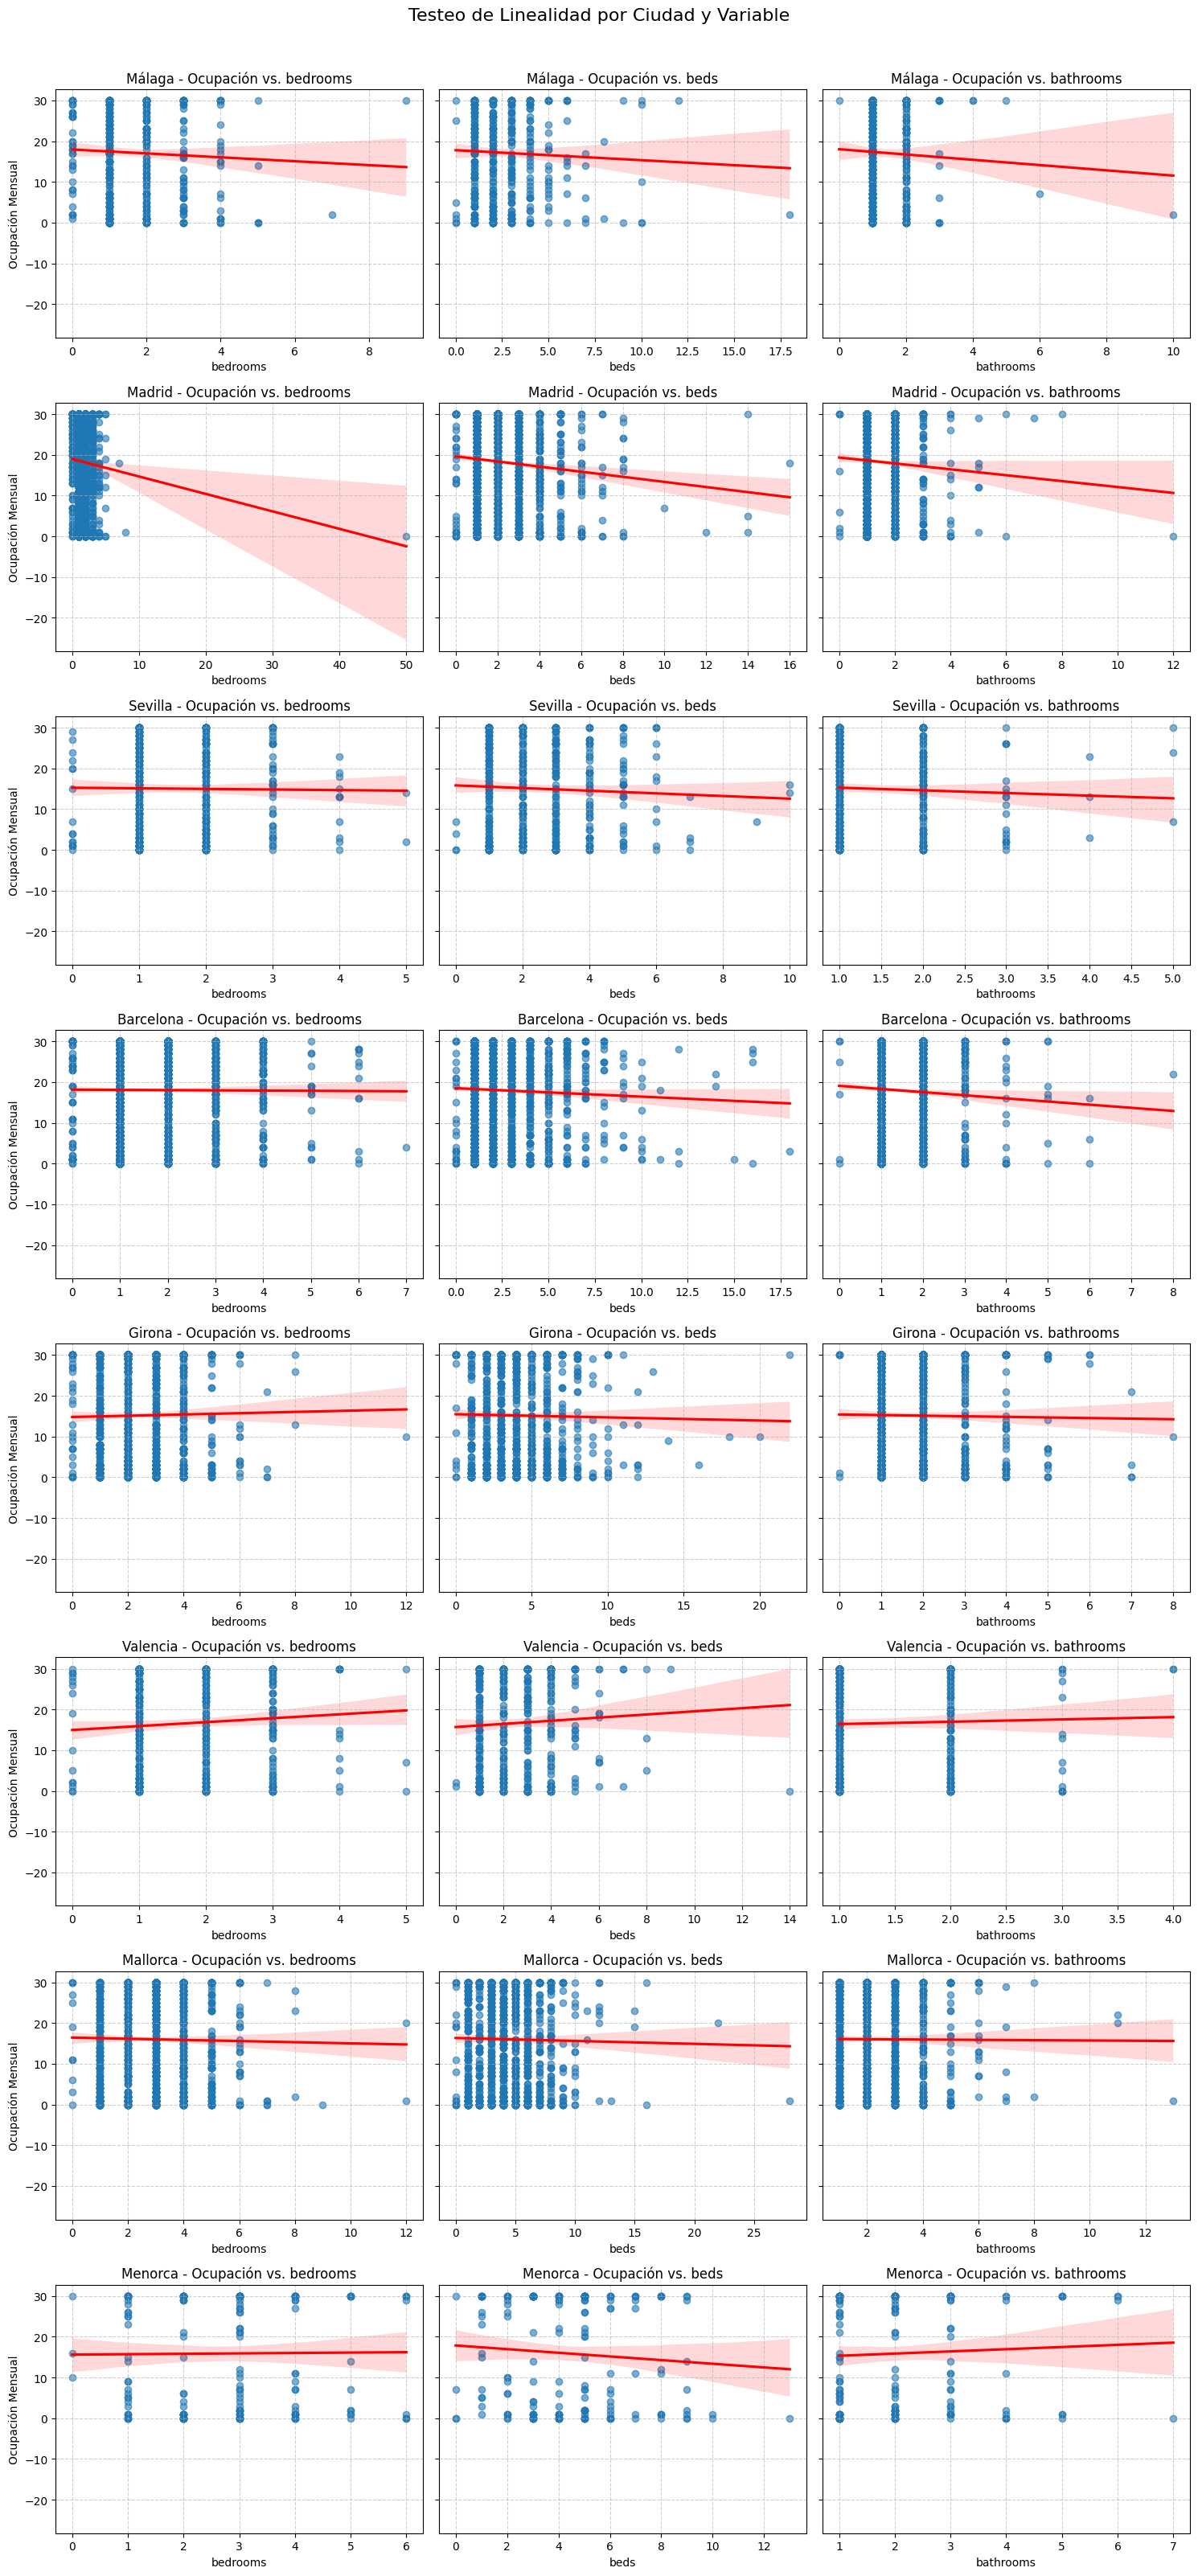

In [21]:
# Variables independientes a testear
variables_x = ['bedrooms', 'beds', 'bathrooms']
ciudades = df['city'].unique()

# Definimos la rejilla: 
# Filas = Número de Ciudades
# Columnas = Número de variables_x
fig, axes = plt.subplots(len(ciudades), len(variables_x), 
                         figsize=(5 * len(variables_x), 4 * len(ciudades)), 
                         sharey=True) # Compartimos el eje Y para facilitar la comparación

# Iteramos sobre las ciudades (Filas)
for i, ciudad in enumerate(ciudades):
    df_ciudad = df[df['city'] == ciudad]
    
    # Iteramos sobre las variables X (Columnas)
    for j, x_var in enumerate(variables_x):
        # Seleccionamos el subplot actual
        ax = axes[i, j] 
        
        # Usamos regplot, pasándole el eje específico 'ax'
        sns.regplot(
            x=x_var, 
            y='ocupacion_mes',
            data=df_ciudad, 
            ax=ax,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'}
        )
        
        # Título para cada gráfico
        ax.set_title(f'{ciudad} - Ocupación vs. {x_var}')
        ax.set_xlabel(x_var)
        ax.set_ylabel('Ocupación Mensual' if j == 0 else '') # Solo la primera columna tiene el label Y
        ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.suptitle('Testeo de Linealidad por Ciudad y Variable', fontsize=16, y=1.0)
# 
plt.show()

# Binning camas:

In [ ]:
# Ejemplo de Agrupación (Binning) para camas
bins = [0, 2, 6, 10, df['beds'].max()] # Define los límites de tus cubetas
labels = ['Baja (1-2)', 'Media (3-6)', 'Alta (7-10)', 'Muy Alta (>10)']

df_limpio = df.copy()
df_limpio['beds_categoria'] = pd.cut(
    df_limpio['beds'], 
    bins=bins, 
    labels=labels, 
    right=True, 
    include_lowest=True
)

# Ahora puedes usar 'beds_categoria' en tu modelo

In [ ]:
df_limpio[['beds_categoria']].value_counts()

beds_categoria
Baja (1-2)        5039
Media (3-6)       3850
Alta (7-10)        467
Muy Alta (>10)      53
Name: count, dtype: int64

# Binning habitaciones:

In [ ]:
# Ejemplo de Agrupación (Binning) para camas
bins = [0, 2, 6, 10, df['bedrooms'].max()] # Define los límites de tus cubetas
labels = ['Baja (1-2)', 'Media (3-4)', 'Alta (5-7)', 'Muy Alta (>7)']

df_limpio['bedrooms_categoria'] = pd.cut(
    df_limpio['bedrooms'], 
    bins=bins, 
    labels=labels, 
    right=True, 
    include_lowest=True
)


In [ ]:
df_limpio[['bedrooms_categoria']].value_counts()

bedrooms_categoria
Baja (1-2)            6910
Media (3-4)           2474
Alta (5-7)              21
Muy Alta (>7)            4
Name: count, dtype: int64

# IQR Baños

C:\Users\irene\AppData\Local\Temp\ipykernel_16036\1474959156.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: ylabel='bathrooms'>

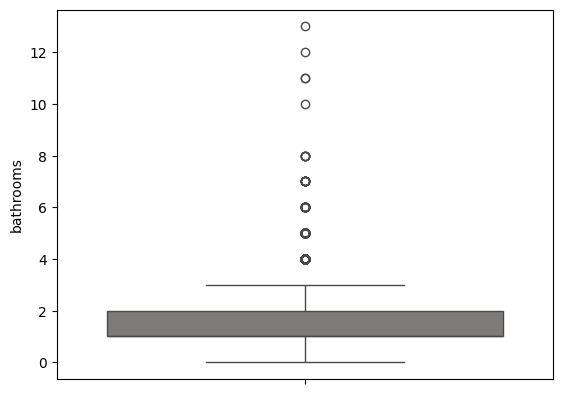

In [ ]:
sns.boxplot(
    data=df,
    y='bathrooms',
    palette='cividis'
)

C:\Users\irene\AppData\Local\Temp\ipykernel_16036\3689129001.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='bathrooms'>

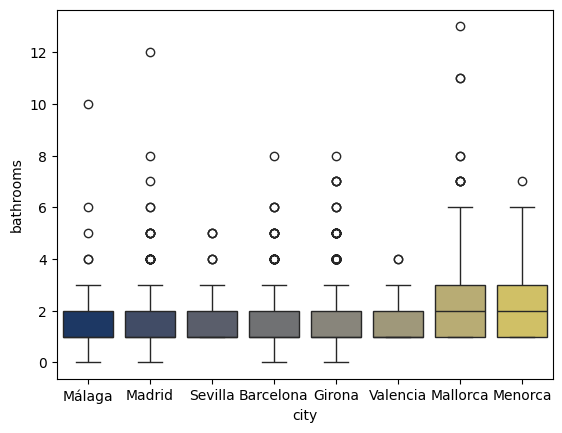

In [ ]:
sns.boxplot(
    data=df,
    x='city',
    y='bathrooms',
    palette='cividis'
)